# Customer Churn Prediction — ML Pipeline Training

## Notebook Contents

1. Task 1: Understand the Dataset
   - Load raw dataset
   - Identify target variable
   - Dataset structure analysis
   - Missing values and duplicates
   - Numerical and categorical features
   - Target distribution and class imbalance
   - Dataset observations

2. Task 2: Create Evaluation Strategy
   - Define features and target
   - Train-validation-test split
   - Evaluation metric selection
   - Reproducibility setup

3. Task 3: Build a Baseline Model
   - Baseline model selection
   - Model training
   - Validation evaluation
   - Baseline performance recording

4. Task 4: Feature Engineering
   - Data cleaning
   - Missing value handling
   - Categorical encoding
   - Numerical feature scaling
   - Feature transformation
   - Domain-based feature creation
   - Leakage check

5. Task 5: Feature Engineering Concepts Documentation
   - Encoding techniques
   - Scaling
   - Imputation
   - Feature transformation
   - Target leakage

6. Task 6: Train Tree-Based Models
   - Random Forest Classifier
   - Gradient Boosting Model
   - Feature importance analysis
   - Bagging vs Boosting explanation

7. Task 7: Hyperparameter Tuning with Cross-Validation
   - RandomizedSearchCV/GridSearchCV
   - Model tuning
   - Best parameters selection

8. Task 8: Fair Model Comparison
   - Baseline vs Random Forest vs Boosting model
   - Performance comparison
   - Final model selection

9. Task 9: Final Test Evaluation
   - Evaluate selected model on untouched test data
   - Compare validation and test performance

10. Task 10: Error Analysis
    - Incorrect predictions analysis
    - Error patterns
    - Possible improvements

11. Task 11: Post-Training Visual Analysis
    - Model comparison chart
    - Confusion matrix
    - ROC curve
    - Precision-Recall curve
    - Feature importance plot
    - Error analysis visualization

12. Task 12: Create and Save Final Pipeline
    - Build complete ML pipeline
    - Fit final pipeline
    - Save pipeline artifact

# Task 1: Understand the Dataset

In this task, we will explore the customer churn dataset, understand the available features, identify the target variable, and analyze the data quality before building machine learning models.

Objectives:
- Load the raw dataset
- Understand dataset structure
- Identify target variable
- Analyze missing values and duplicates
- Separate numerical and categorical features
- Check target distribution and class imbalance
- Document important observations

In [1]:
# Data manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Display settings
pd.set_option('display.max_columns', None)

# Ignore warnings
import warnings
warnings.filterwarnings('ignore')

## 1.1 Load Dataset

In [2]:
import pandas as pd

df = pd.read_excel(
    "dataset/Telco_customer_churn.xlsx"
)

df.head()

,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,Senior Citizen,Partner,Dependents,Tenure Months,Phone Service,Multiple Lines,Internet Service,Online Security,Online Backup,Device Protection,Tech Support,Streaming TV,Streaming Movies,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
0,3668-QPYBK,1,United States,California,Los Angeles,90003,"33.964131, -118.272783",33.964131,-118.272783,Male,No,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,86,3239,Competitor made better offer
1,9237-HQITU,1,United States,California,Los Angeles,90005,"34.059281, -118.30742",34.059281,-118.307420,Female,No,No,Yes,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,67,2701,Moved
2,9305-CDSKC,1,United States,California,Los Angeles,90006,"34.048013, -118.293953",34.048013,-118.293953,Female,No,No,Yes,8,Yes,Yes,Fiber optic,No,No,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.5,Yes,1,86,5372,Moved
3,7892-POOKP,1,United States,California,Los Angeles,90010,"34.062125, -118.315709",34.062125,-118.315709,Female,No,Yes,Yes,28,Yes,Yes,Fiber optic,No,No,Yes,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes,1,84,5003,Moved
4,0280-XJGEX,1,United States,California,Los Angeles,90015,"34.039224, -118.266293",34.039224,-118.266293,Male,No,No,Yes,49,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.3,Yes,1,89,5340,Competitor had better devices


## 1.2 Dataset Overview

In this section, we inspect the basic structure of the dataset including the number of records, features, column names, and data types.

In [3]:
df.shape

(7043, 33)

In [4]:
df.columns

Index(['CustomerID', 'Count', 'Country', 'State', 'City', 'Zip Code',
       'Lat Long', 'Latitude', 'Longitude', 'Gender', 'Senior Citizen',
       'Partner', 'Dependents', 'Tenure Months', 'Phone Service',
       'Multiple Lines', 'Internet Service', 'Online Security',
       'Online Backup', 'Device Protection', 'Tech Support', 'Streaming TV',
       'Streaming Movies', 'Contract', 'Paperless Billing', 'Payment Method',
       'Monthly Charges', 'Total Charges', 'Churn Label', 'Churn Value',
       'Churn Score', 'CLTV', 'Churn Reason'],
      dtype='object')

## 1.3 Data Type Analysis

This section examines the data types of all features and identifies potential preprocessing requirements before model training.

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 33 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         7043 non-null   object 
 1   Count              7043 non-null   int64  
 2   Country            7043 non-null   object 
 3   State              7043 non-null   object 
 4   City               7043 non-null   object 
 5   Zip Code           7043 non-null   int64  
 6   Lat Long           7043 non-null   object 
 7   Latitude           7043 non-null   float64
 8   Longitude          7043 non-null   float64
 9   Gender             7043 non-null   object 
 10  Senior Citizen     7043 non-null   object 
 11  Partner            7043 non-null   object 
 12  Dependents         7043 non-null   object 
 13  Tenure Months      7043 non-null   int64  
 14  Phone Service      7043 non-null   object 
 15  Multiple Lines     7043 non-null   object 
 16  Internet Service   7043 

## Task 1.4 — Missing Value Analysis using

In [6]:
df.isnull().sum()

CustomerID              0
Count                   0
Country                 0
State                   0
City                    0
Zip Code                0
Lat Long                0
Latitude                0
Longitude               0
Gender                  0
Senior Citizen          0
Partner                 0
Dependents              0
Tenure Months           0
Phone Service           0
Multiple Lines          0
Internet Service        0
Online Security         0
Online Backup           0
Device Protection       0
Tech Support            0
Streaming TV            0
Streaming Movies        0
Contract                0
Paperless Billing       0
Payment Method          0
Monthly Charges         0
Total Charges           0
Churn Label             0
Churn Value             0
Churn Score             0
CLTV                    0
Churn Reason         5174
dtype: int64

### Missing Value Observation

The dataset contains no missing values in most features. The `Churn Reason` column contains missing values because reasons are only recorded for customers who have already churned.

Since `Churn Reason` provides direct information about the target outcome, it will be removed during preprocessing to prevent target leakage.

## 1.5 Duplicate Record Analysis

In [7]:
df.duplicated().sum()

np.int64(0)

### Duplicate Record Observation

The dataset does not contain any duplicate records. Each customer entry represents a unique observation, so no duplicate removal is required at this stage.

## 1.6 Feature Type Identification

The dataset contains both numerical and categorical features. Identifying these feature types is important because different preprocessing techniques will be applied before model training.

In [8]:
numerical_features = df.select_dtypes(include=['int64', 'float64']).columns

numerical_features

Index(['Count', 'Zip Code', 'Latitude', 'Longitude', 'Tenure Months',
       'Monthly Charges', 'Churn Value', 'Churn Score', 'CLTV'],
      dtype='object')

In [9]:
categorical_features = df.select_dtypes(include=['object']).columns

categorical_features

Index(['CustomerID', 'Country', 'State', 'City', 'Lat Long', 'Gender',
       'Senior Citizen', 'Partner', 'Dependents', 'Phone Service',
       'Multiple Lines', 'Internet Service', 'Online Security',
       'Online Backup', 'Device Protection', 'Tech Support', 'Streaming TV',
       'Streaming Movies', 'Contract', 'Paperless Billing', 'Payment Method',
       'Total Charges', 'Churn Label', 'Churn Reason'],
      dtype='object')

## Task 1.7 — Identify Target Variable

In [10]:
df.columns

Index(['CustomerID', 'Count', 'Country', 'State', 'City', 'Zip Code',
       'Lat Long', 'Latitude', 'Longitude', 'Gender', 'Senior Citizen',
       'Partner', 'Dependents', 'Tenure Months', 'Phone Service',
       'Multiple Lines', 'Internet Service', 'Online Security',
       'Online Backup', 'Device Protection', 'Tech Support', 'Streaming TV',
       'Streaming Movies', 'Contract', 'Paperless Billing', 'Payment Method',
       'Monthly Charges', 'Total Charges', 'Churn Label', 'Churn Value',
       'Churn Score', 'CLTV', 'Churn Reason'],
      dtype='object')

In [11]:
df['Churn Value'].value_counts()

Churn Value
0    5174
1    1869
Name: count, dtype: int64

### Target Variable Selection

The target variable selected for this classification problem is `Churn Value`.

- 0 represents customers who did not churn.
- 1 represents customers who churned.

Other churn-related columns such as `Churn Label`, `Churn Score`, and `Churn Reason` will not be used as input features because they can introduce target leakage.

## 1.8 Target Distribution Analysis

The target variable distribution is analyzed to understand the proportion of customers who churned and those who continued using the service.

This helps identify class imbalance, which can affect model training and evaluation.

In [12]:
df['Churn Value'].value_counts()

Churn Value
0    5174
1    1869
Name: count, dtype: int64

In [13]:
df['Churn Value'].value_counts(normalize=True) * 100

Churn Value
0    73.463013
1    26.536987
Name: proportion, dtype: float64

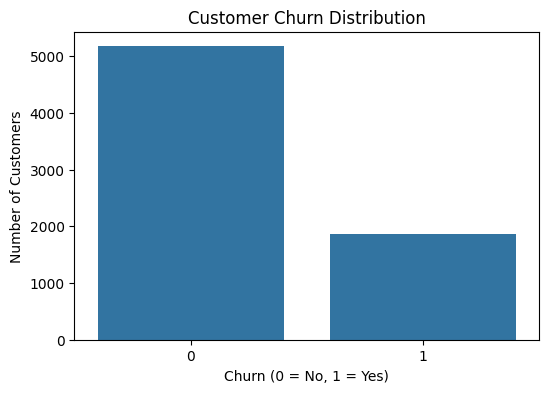

In [14]:
plt.figure(figsize=(6,4))

sns.countplot(
    x='Churn Value',
    data=df
)

plt.title("Customer Churn Distribution")
plt.xlabel("Churn (0 = No, 1 = Yes)")
plt.ylabel("Number of Customers")

plt.show()

## 1.9 Dataset Observations

Based on the initial exploration of the dataset, the following observations were made:

1. The dataset contains customer information related to demographics, services, billing, and subscription details that can be used for churn prediction.

2. The target variable `Churn Value` is imbalanced, with a higher number of customers who stayed compared to customers who churned.

3. The dataset contains both numerical and categorical features. Numerical features will require appropriate preprocessing, while categorical features will require encoding before model training.

4. The columns `Churn Label`, `Churn Score`, and `Churn Reason` will be excluded from model features because they provide direct information about churn and may cause target leakage.

# Task 2: Create Evaluation Strategy

## 2.1 Define Features and Target Variable

Before training the model, the dataset is prepared by separating input features and the target variable. Columns that directly reveal churn information are removed to prevent target leakage.

In [15]:
# Create a copy for modelling
data = df.copy()

# Remove leakage columns
leakage_columns = [
    'Churn Label',
    'Churn Score',
    'Churn Reason'
]

data = data.drop(columns=leakage_columns)

data.head()

,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,Senior Citizen,Partner,Dependents,Tenure Months,Phone Service,Multiple Lines,Internet Service,Online Security,Online Backup,Device Protection,Tech Support,Streaming TV,Streaming Movies,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Value,CLTV
0,3668-QPYBK,1,United States,California,Los Angeles,90003,"33.964131, -118.272783",33.964131,-118.272783,Male,No,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1,3239
1,9237-HQITU,1,United States,California,Los Angeles,90005,"34.059281, -118.30742",34.059281,-118.307420,Female,No,No,Yes,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1,2701
2,9305-CDSKC,1,United States,California,Los Angeles,90006,"34.048013, -118.293953",34.048013,-118.293953,Female,No,No,Yes,8,Yes,Yes,Fiber optic,No,No,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.5,1,5372
3,7892-POOKP,1,United States,California,Los Angeles,90010,"34.062125, -118.315709",34.062125,-118.315709,Female,No,Yes,Yes,28,Yes,Yes,Fiber optic,No,No,Yes,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,104.80,3046.05,1,5003
4,0280-XJGEX,1,United States,California,Los Angeles,90015,"34.039224, -118.266293",34.039224,-118.266293,Male,No,No,Yes,49,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.3,1,5340


## 2.2 Separate Features and Target

The dataset is divided into input features (X) and the target variable (y).

- X contains customer-related information used for prediction.
- y contains the churn outcome that the model will learn to predict.

In [16]:
# Define target variable

target = 'Churn Value'

X = data.drop(columns=[target])
y = data[target]

# Check dimensions

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (7043, 29)
Target shape: (7043,)


## 2.3 Train, Validation and Test Split

The dataset is divided into three parts:

- Training set: Used to train the machine learning model.
- Validation set: Used for model comparison and hyperparameter tuning.
- Test set: Kept completely unseen and used only for final evaluation.

A fixed random state is used to ensure reproducibility.

In [17]:
from sklearn.model_selection import train_test_split

In [18]:
# First split: Training + Temporary set

X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42,
    stratify=y
)


# Second split: Validation + Test

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.5,
    random_state=42,
    stratify=y_temp
)


print("Training set:", X_train.shape)
print("Validation set:", X_val.shape)
print("Test set:", X_test.shape)

Training set: (4930, 29)
Validation set: (1056, 29)
Test set: (1057, 29)


## Reproducibility

A fixed random seed (`random_state=42`) is used during dataset splitting to ensure that the same train, validation, and test sets are generated every time the notebook is executed.

## 2.4 Evaluation Metric Selection

Since customer churn prediction is a classification problem with imbalanced classes, multiple evaluation metrics will be considered.

The primary metric selected for model comparison is ROC-AUC because it evaluates the model's ability to distinguish between churn and non-churn customers across different classification thresholds.

Additional metrics such as Precision, Recall, and F1-score will also be monitored to understand the model's performance, especially for identifying churned customers.

In [19]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

## Test Set Protection

The test dataset will not be used during model training, feature selection, or hyperparameter tuning.

It will only be evaluated once after the final model is selected to measure the model's generalization performance on unseen data.

# Task 3: Build a Baseline Model

A baseline model is developed to establish a reference performance before applying advanced feature engineering and complex machine learning models.

Logistic Regression is selected as the baseline classifier because it is a simple and interpretable algorithm for binary classification problems.

## 3.1 Baseline Preprocessing

In [20]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

In [21]:
# Convert Total Charges to numeric

X_train['Total Charges'] = pd.to_numeric(
    X_train['Total Charges'],
    errors='coerce'
)

X_val['Total Charges'] = pd.to_numeric(
    X_val['Total Charges'],
    errors='coerce'
)

X_test['Total Charges'] = pd.to_numeric(
    X_test['Total Charges'],
    errors='coerce'
)

In [22]:
# Identify numerical and categorical columns

numerical_features = X_train.select_dtypes(
    include=['int64', 'float64']
).columns

categorical_features = X_train.select_dtypes(
    include=['object']
).columns


print("Numerical Features:")
print(list(numerical_features))

print("\nCategorical Features:")
print(list(categorical_features))

Numerical Features:
['Count', 'Zip Code', 'Latitude', 'Longitude', 'Tenure Months', 'Monthly Charges', 'Total Charges', 'CLTV']

Categorical Features:
['CustomerID', 'Country', 'State', 'City', 'Lat Long', 'Gender', 'Senior Citizen', 'Partner', 'Dependents', 'Phone Service', 'Multiple Lines', 'Internet Service', 'Online Security', 'Online Backup', 'Device Protection', 'Tech Support', 'Streaming TV', 'Streaming Movies', 'Contract', 'Paperless Billing', 'Payment Method']


## 3.2 Create Baseline Preprocessing Pipeline

Numerical features are processed using:
- Median imputation for missing values
- Standard scaling for normalization

Categorical features are processed using:
- Most frequent value imputation
- One-hot encoding for converting categories into numerical form

In [23]:
# Numerical preprocessing pipeline

numerical_pipeline = Pipeline(
    steps=[
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler())
    ]
)


# Categorical preprocessing pipeline

categorical_pipeline = Pipeline(
    steps=[
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('encoder', OneHotEncoder(handle_unknown='ignore'))
    ]
)

## 3.3 Combine Preprocessing Steps

The numerical and categorical preprocessing pipelines are combined using `ColumnTransformer`.

This allows different preprocessing operations to be applied automatically to different feature types before model training.

In [24]:
# Combine preprocessing pipelines

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_pipeline, numerical_features),
        ('cat', categorical_pipeline, categorical_features)
    ]
)

## 3.4 Build Logistic Regression Baseline Pipeline

The preprocessing steps and Logistic Regression classifier are combined into a single pipeline to ensure consistent data transformation during training and prediction.

In [25]:
from sklearn.linear_model import LogisticRegression


baseline_model = Pipeline(
    steps=[
        ('preprocessor', preprocessor),
        ('classifier', LogisticRegression(max_iter=1000))
    ]
)

## 3.5 Train Baseline Logistic Regression Model

The baseline pipeline is trained using the training dataset. The model learns patterns from customer features and will be evaluated on the validation dataset.

In [26]:
# Train baseline model

baseline_model.fit(
    X_train,
    y_train
)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](29,)","['CustomerID','Count','Country',...,'Monthly Charges','Total Charges', 'CLTV']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,29
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthro

## 3.6 Baseline Model Evaluation

The trained baseline model is evaluated on the validation dataset using classification metrics.

In [27]:
# Generate predictions on validation data

y_val_pred = baseline_model.predict(X_val)

# Generate probability predictions for ROC-AUC

y_val_prob = baseline_model.predict_proba(X_val)[:, 1]

In [28]:
# Calculate baseline performance

baseline_results = {
    "Accuracy": accuracy_score(y_val, y_val_pred),
    "Precision": precision_score(y_val, y_val_pred),
    "Recall": recall_score(y_val, y_val_pred),
    "F1 Score": f1_score(y_val, y_val_pred),
    "ROC-AUC": roc_auc_score(y_val, y_val_prob)
}

baseline_results

{'Accuracy': 0.7784090909090909,
 'Precision': 0.5815602836879432,
 'Recall': 0.5857142857142857,
 'F1 Score': 0.5836298932384342,
 'ROC-AUC': 0.8348536450662739}

## Step 3.7 — Baseline Performance Results

In [29]:
# Calculate baseline performance

baseline_results = {
    "Accuracy": accuracy_score(y_val, y_val_pred),
    "Precision": precision_score(y_val, y_val_pred),
    "Recall": recall_score(y_val, y_val_pred),
    "F1 Score": f1_score(y_val, y_val_pred),
    "ROC-AUC": roc_auc_score(y_val, y_val_prob)
}

baseline_results

{'Accuracy': 0.7784090909090909,
 'Precision': 0.5815602836879432,
 'Recall': 0.5857142857142857,
 'F1 Score': 0.5836298932384342,
 'ROC-AUC': 0.8348536450662739}

### Baseline Model Observation

The Logistic Regression model provides a baseline performance for the churn prediction problem.

The baseline ROC-AUC score achieved on the validation dataset is **0.835**.

This ROC-AUC score will be used as the primary comparison metric for evaluating future models. Other metrics such as precision, recall, and F1-score are also considered because the dataset contains class imbalance.

# Task 4: Feature Engineering

Feature engineering is performed to create meaningful variables from existing customer information.

New features are created based on customer tenure, service usage, and billing behaviour to improve churn prediction performance.

In [30]:
# Create a separate copy for feature engineering

data_fe = data.copy()

data_fe.head()

,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,Senior Citizen,Partner,Dependents,Tenure Months,Phone Service,Multiple Lines,Internet Service,Online Security,Online Backup,Device Protection,Tech Support,Streaming TV,Streaming Movies,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Value,CLTV
0,3668-QPYBK,1,United States,California,Los Angeles,90003,"33.964131, -118.272783",33.964131,-118.272783,Male,No,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1,3239
1,9237-HQITU,1,United States,California,Los Angeles,90005,"34.059281, -118.30742",34.059281,-118.307420,Female,No,No,Yes,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1,2701
2,9305-CDSKC,1,United States,California,Los Angeles,90006,"34.048013, -118.293953",34.048013,-118.293953,Female,No,No,Yes,8,Yes,Yes,Fiber optic,No,No,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.5,1,5372
3,7892-POOKP,1,United States,California,Los Angeles,90010,"34.062125, -118.315709",34.062125,-118.315709,Female,No,Yes,Yes,28,Yes,Yes,Fiber optic,No,No,Yes,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,104.80,3046.05,1,5003
4,0280-XJGEX,1,United States,California,Los Angeles,90015,"34.039224, -118.266293",34.039224,-118.266293,Male,No,No,Yes,49,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.3,1,5340


## 4.1 Leakage Check

Before creating new features, columns that directly reveal the target outcome are removed. These features would not be available at prediction time and can cause target leakage.

In [31]:
# Remove target leakage columns if they exist

leakage_columns = [
    'Churn Label',
    'Churn Score',
    'Churn Reason'
]

data_fe = data_fe.drop(
    columns=leakage_columns,
    errors='ignore'
)

data_fe.head()

,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,Senior Citizen,Partner,Dependents,Tenure Months,Phone Service,Multiple Lines,Internet Service,Online Security,Online Backup,Device Protection,Tech Support,Streaming TV,Streaming Movies,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Value,CLTV
0,3668-QPYBK,1,United States,California,Los Angeles,90003,"33.964131, -118.272783",33.964131,-118.272783,Male,No,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1,3239
1,9237-HQITU,1,United States,California,Los Angeles,90005,"34.059281, -118.30742",34.059281,-118.307420,Female,No,No,Yes,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1,2701
2,9305-CDSKC,1,United States,California,Los Angeles,90006,"34.048013, -118.293953",34.048013,-118.293953,Female,No,No,Yes,8,Yes,Yes,Fiber optic,No,No,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.5,1,5372
3,7892-POOKP,1,United States,California,Los Angeles,90010,"34.062125, -118.315709",34.062125,-118.315709,Female,No,Yes,Yes,28,Yes,Yes,Fiber optic,No,No,Yes,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,104.80,3046.05,1,5003
4,0280-XJGEX,1,United States,California,Los Angeles,90015,"34.039224, -118.266293",34.039224,-118.266293,Male,No,No,Yes,49,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.3,1,5340


### Leakage Check Observation

The columns Churn Label, Churn Score, and Churn Reason were removed because they contain direct information about customer churn. Including them would result in target leakage and unrealistic model performance.

## 4.2 Creating Domain-Based Features

New features are created using customer billing behaviour, service usage, and subscription information to better represent churn-related patterns.

### Feature 1 — Average Monthly Spend

This feature represents the average amount spent by a customer per month. It helps capture customer billing behaviour and identify high-value customers who may require retention strategies.

In [32]:
# Convert Total Charges into numeric format

data_fe['Total Charges'] = pd.to_numeric(
    data_fe['Total Charges'],
    errors='coerce'
)

In [33]:
data_fe[['Total Charges','Tenure Months']].dtypes

Total Charges    float64
Tenure Months      int64
dtype: object

In [34]:
# Feature 1: Average Monthly Spend

data_fe['Avg_Monthly_Spend'] = (
    data_fe['Total Charges'] /
    data_fe['Tenure Months']
)

data_fe[['Total Charges','Tenure Months','Avg_Monthly_Spend']].head()

,Total Charges,Tenure Months,Avg_Monthly_Spend
0,108.15,2,54.075000
1,151.65,2,75.825000
2,820.50,8,102.562500
3,3046.05,28,108.787500
4,5036.30,49,102.781633


### Feature 2 — Total Services Used

This feature represents customer engagement by counting the number of services used by each customer. Customers with fewer services may have lower engagement and potentially higher churn risk.

In [35]:
# Feature 2: Total Services Used

data_fe['Total_Services'] = (
    (data_fe['Phone Service'] == 'Yes').astype(int)
    +
    (data_fe['Internet Service'] != 'No').astype(int)
    +
    (data_fe['Online Security'] == 'Yes').astype(int)
    +
    (data_fe['Tech Support'] == 'Yes').astype(int)
)

data_fe[
[
    'Phone Service',
    'Internet Service',
    'Online Security',
    'Tech Support',
    'Total_Services'
]
].head()

,Phone Service,Internet Service,Online Security,Tech Support,Total_Services
0,Yes,DSL,Yes,No,3
1,Yes,Fiber optic,No,No,2
2,Yes,Fiber optic,No,No,2
3,Yes,Fiber optic,No,Yes,3
4,Yes,Fiber optic,No,No,2


### Feature 3 — Tenure Category

This feature groups customers based on their tenure duration. It captures different customer lifecycle stages because new and long-term customers may show different churn behaviour.

In [36]:
data_fe['Tenure_Category'] = pd.cut(
    data_fe['Tenure Months'],
    bins=[0, 12, 36, 72],
    labels=['New', 'Medium', 'Long'],
    include_lowest=True
)

### Feature 4 — Contract Risk

This feature captures the customer's contract commitment level. Month-to-month customers have more flexibility to leave, so they may have a higher churn risk compared to customers with longer contracts.

In [37]:
# Feature 4: Contract Risk

import numpy as np

data_fe['Contract_Risk'] = np.where(
    data_fe['Contract'] == 'Month-to-month',
    'High',
    'Low'
)

data_fe[
[
    'Contract',
    'Contract_Risk'
]
].head()

,Contract,Contract_Risk
0,Month-to-month,High
1,Month-to-month,High
2,Month-to-month,High
3,Month-to-month,High
4,Month-to-month,High


### Feature 5 — Log Transformation of Total Charges

A logarithmic transformation is applied to Total Charges to reduce the effect of highly skewed values. This helps linear models learn better patterns when some customers have very high lifetime spending.

In [38]:
# Feature 5: Log transformation of Total Charges

data_fe['Log_Total_Charges'] = np.log1p(
    data_fe['Total Charges']
)

data_fe[
[
    'Total Charges',
    'Log_Total_Charges'
]
].head()

,Total Charges,Log_Total_Charges
0,108.15,4.692723
1,151.65,5.028148
2,820.50,6.711132
3,3046.05,8.021929
4,5036.30,8.524626


## Feature Engineering Decisions

### Categorical Encoding

Categorical variables were converted into numerical format using One-Hot Encoding.

One-Hot Encoding was selected because most customer attributes such as Contract, Payment Method, and Internet Service are nominal categories without any natural ordering.

Ordinal or Label Encoding is suitable when categories have a meaningful ranking (for example: Low, Medium, High). However, applying it to nominal variables may introduce false relationships between categories.

Target/Mean Encoding was not used in this project because it requires careful handling to prevent target leakage. If target information is used from the complete dataset during encoding, it can result in unrealistic model performance.

---

### Scaling

Numerical features were scaled using StandardScaler.

Scaling is important for Logistic Regression because the model learns feature coefficients, and features with larger ranges can dominate the optimization process.

Tree-based models such as Decision Trees and Random Forests generally do not require scaling because they make decisions using feature split thresholds rather than feature magnitude.

---

### Missing Value Handling

Missing numerical values were handled using median imputation.

The median strategy was selected because it is less affected by outliers and provides a robust estimate for numerical features.

Missing categorical values were handled using most-frequent imputation because it replaces missing values with the most common category and preserves existing customer behaviour patterns.

---

### Feature Transformation

A logarithmic transformation was applied to the Total Charges feature.

The transformed feature `Log_Total_Charges` reduces the effect of highly skewed spending values and helps the Logistic Regression model learn better patterns from customer billing behaviour.

---

### Domain-Based Features

Four domain-based features were created using customer billing behaviour, service usage, and subscription information.

**1. Avg_Monthly_Spend**

- Calculates the average monthly spending of a customer.
- Helps capture customer billing behaviour and spending patterns.

**2. Total_Services**

- Represents the number of services used by each customer.
- Helps measure customer engagement level.

**3. Tenure_Category**

- Groups customers into New, Medium, and Long tenure categories.
- Helps capture different customer lifecycle stages.

**4. Contract_Risk**

- Identifies month-to-month contract customers as higher risk.
- Helps represent churn risk based on customer commitment level.

---

### Leakage Check

Features containing direct information about customer churn were removed before model training.

The removed columns were:

- Churn Label
- Churn Score
- Churn Reason

These features were excluded because they contain information about the target variable and would not be available during real-world prediction. Including them would cause target leakage and unrealistic model performance.

## Preparing the Feature-Engineered Preprocessing Pipeline

The feature-engineered dataset contains additional numerical and categorical variables. A dedicated preprocessing pipeline is created to ensure that these features are handled consistently during model training, validation, and prediction.

In [39]:
# Create feature-engineered versions of the existing data splits

X_train_fe = data_fe.loc[X_train.index].drop(
    columns=["Churn Value"],
    errors="ignore"
).copy()

X_val_fe = data_fe.loc[X_val.index].drop(
    columns=["Churn Value"],
    errors="ignore"
).copy()

X_test_fe = data_fe.loc[X_test.index].drop(
    columns=["Churn Value"],
    errors="ignore"
).copy()

print("Feature-engineered train shape:", X_train_fe.shape)
print("Feature-engineered validation shape:", X_val_fe.shape)
print("Feature-engineered test shape:", X_test_fe.shape)

Feature-engineered train shape: (4930, 34)
Feature-engineered validation shape: (1056, 34)
Feature-engineered test shape: (1057, 34)


In [40]:
# Identify numerical and categorical features

numerical_features_fe = X_train_fe.select_dtypes(
    include=['int64', 'float64']
).columns.tolist()

categorical_features_fe = X_train_fe.select_dtypes(
    include=['object', 'category']
).columns.tolist()

In [41]:
# Numerical preprocessing

numerical_pipeline_fe = Pipeline(
    steps=[
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler())
    ]
)

# Categorical preprocessing

categorical_pipeline_fe = Pipeline(
    steps=[
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('encoder', OneHotEncoder(handle_unknown='ignore'))
    ]
)

In [42]:
# Feature-engineered preprocessing pipeline

preprocessor_fe = ColumnTransformer(
    transformers=[
        ('num', numerical_pipeline_fe, numerical_features_fe),
        ('cat', categorical_pipeline_fe, categorical_features_fe)
    ]
)

In [43]:
from sklearn.ensemble import RandomForestClassifier
rf_model = Pipeline(
    steps=[
        ('preprocessor', preprocessor_fe),
        ('classifier', RandomForestClassifier(
            n_estimators=200,
            random_state=42
        ))
    ]
)

# Feature Engineering Summary

Feature engineering was performed to convert raw customer information into meaningful machine learning features.

The following transformations were applied:

1. **Categorical Encoding**
   - Categorical variables were converted using One-Hot Encoding.
   - This allows machine learning models to process non-numerical customer attributes.

2. **Feature Scaling**
   - Numerical features were standardized using StandardScaler.
   - Scaling improves the performance of distance and coefficient-based models such as Logistic Regression.

3. **Missing Value Handling**
   - Numerical features were handled using median imputation.
   - Categorical features were handled using most-frequent imputation.

4. **Domain-Based Features**
   - Avg_Monthly_Spend was created to represent customer spending behaviour.
   - Total_Services was created to measure customer engagement.
   - Tenure_Category was created to represent customer lifecycle stage.
   - Contract_Risk was created to identify customers with higher churn probability.

5. **Feature Transformation**
   - Log_Total_Charges was created using logarithmic transformation to reduce skewness in customer spending values.

6. **Leakage Prevention**
   - Churn-related columns containing direct target information were removed before model training.

## Note on Documentation

The feature engineering concepts and theoretical explanations required in Task 5 have been documented separately in README.md under the section "Feature Engineering Concepts".

# Task 6: Train Tree-Based Models

After feature engineering, tree-based machine learning models are trained and evaluated using the same validation strategy.

Tree-based models are used because they can capture complex non-linear relationships and interactions between customer features.

The following models are implemented:

1. Random Forest Classifier
2. Gradient Boosting Model (XGBoost)

## 6.1 Random Forest Classifier

Random Forest is a bagging-based ensemble method that combines multiple decision trees.

Each tree is trained independently using a different bootstrap sample of the training data, and the individual predictions are aggregated to produce the final prediction.

Random Forest is used to capture non-linear relationships in the customer churn data and provide a tree-based comparison with the Logistic Regression baseline.

In [44]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline

rf_model = Pipeline(
    steps=[
        ('preprocessor', preprocessor_fe),
        ('classifier', RandomForestClassifier(
            n_estimators=200,
            random_state=42
        ))
    ]
)

In [45]:
rf_model.fit(
    X_train_fe,
    y_train
)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](34,)","['CustomerID','Count','Country',...,'Tenure_Category','Contract_Risk', 'Log_Total_Charges']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,34
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remain

In [46]:
y_val_pred_rf = rf_model.predict(X_val_fe)

y_val_prob_rf = rf_model.predict_proba(X_val_fe)[:, 1]

### Random Forest Validation Performance

The trained Random Forest model is evaluated on the validation dataset using the same metrics used for the baseline model.

In [47]:
rf_results = {
    "Accuracy": accuracy_score(y_val, y_val_pred_rf),
    "Precision": precision_score(y_val, y_val_pred_rf),
    "Recall": recall_score(y_val, y_val_pred_rf),
    "F1 Score": f1_score(y_val, y_val_pred_rf),
    "ROC-AUC": roc_auc_score(y_val, y_val_prob_rf)
}

rf_results

{'Accuracy': 0.7954545454545454,
 'Precision': 0.6403508771929824,
 'Recall': 0.5214285714285715,
 'F1 Score': 0.5748031496062992,
 'ROC-AUC': 0.8413843888070692}

## 6.2 Gradient Boosting Model (XGBoost)

XGBoost is a gradient-boosting ensemble method that builds decision trees sequentially, with each new tree focusing on correcting the errors made by previous trees.

XGBoost is used to capture non-linear relationships and interactions between customer features and to compare boosting performance with Random Forest.

In [48]:
from xgboost import XGBClassifier

xgb_model = Pipeline(
    steps=[
        ('preprocessor', preprocessor_fe),
        ('classifier', XGBClassifier(
            n_estimators=200,
            learning_rate=0.05,
            max_depth=4,
            random_state=42,
            eval_metric='logloss'
        ))
    ]
)

In [49]:
xgb_model.fit(
    X_train_fe,
    y_train
)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](34,)","['CustomerID','Count','Country',...,'Tenure_Category','Contract_Risk', 'Log_Total_Charges']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,34
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remain

In [50]:
# Validation Predictions:
y_val_pred_xgb = xgb_model.predict(X_val_fe)

y_val_prob_xgb = xgb_model.predict_proba(X_val_fe)[:, 1]

### XGBoost Validation Performance

The trained XGBoost model is evaluated on the same validation dataset and using the same metrics as the Random Forest model.

In [51]:
xgb_results = {
    "Accuracy": accuracy_score(y_val, y_val_pred_xgb),
    "Precision": precision_score(y_val, y_val_pred_xgb),
    "Recall": recall_score(y_val, y_val_pred_xgb),
    "F1 Score": f1_score(y_val, y_val_pred_xgb),
    "ROC-AUC": roc_auc_score(y_val, y_val_prob_xgb)
}

xgb_results

{'Accuracy': 0.7935606060606061,
 'Precision': 0.6192307692307693,
 'Recall': 0.575,
 'F1 Score': 0.5962962962962963,
 'ROC-AUC': 0.853134204712813}

## 6.3 Validation Strategy

Both Random Forest and XGBoost were evaluated using the same validation dataset and the same evaluation metrics.

Using an identical validation strategy ensures that the performance of the two tree-based models can be compared fairly.

In [52]:
model_comparison_tree = pd.DataFrame(
    [rf_results, xgb_results],
    index=[
        "Random Forest",
        "XGBoost"
    ]
)

model_comparison_tree

,Accuracy,Precision,Recall,F1 Score,ROC-AUC
Random Forest,0.795455,0.640351,0.521429,0.574803,0.841384
XGBoost,0.793561,0.619231,0.575000,0.596296,0.853134


### Tree-Based Model Comparison

XGBoost achieves stronger validation performance than Random Forest, particularly in terms of recall, F1-score, and ROC-AUC.

The results indicate that the sequential error-correction approach of boosting captures useful churn patterns that are not captured as effectively by the Random Forest model.

## 6.4 Feature Importance Analysis

Feature importance is examined using the trained XGBoost model to identify which customer attributes contribute most to churn prediction.

The importance scores help interpret the model and identify customer characteristics that have the greatest influence on its predictions.

In [53]:
# Extract feature names after preprocessing

feature_names = xgb_model.named_steps[
    'preprocessor'
].get_feature_names_out()

# Extract XGBoost feature importance

importance_values = xgb_model.named_steps[
    'classifier'
].feature_importances_

# Create feature importance dataframe

feature_importance = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importance_values
})

# Sort by importance

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

feature_importance.head(15)

,Feature,Importance
7745,cat__Contract_Month-to-month,0.299677
7725,cat__Internet Service_Fiber optic,0.159390
7736,cat__Tech Support_No,0.044499
7727,cat__Online Security_No,0.036470
7717,cat__Dependents_No,0.036049
7752,cat__Payment Method_Electronic check,0.034119
7747,cat__Contract_Two year,0.024251
7746,cat__Contract_One year,0.023995
4,num__Tenure Months,0.021027
7723,cat__Multiple Lines_Yes,0.020033


### Feature Importance Visualization

The top 15 features are visualized to make the most influential customer attributes easier to interpret.

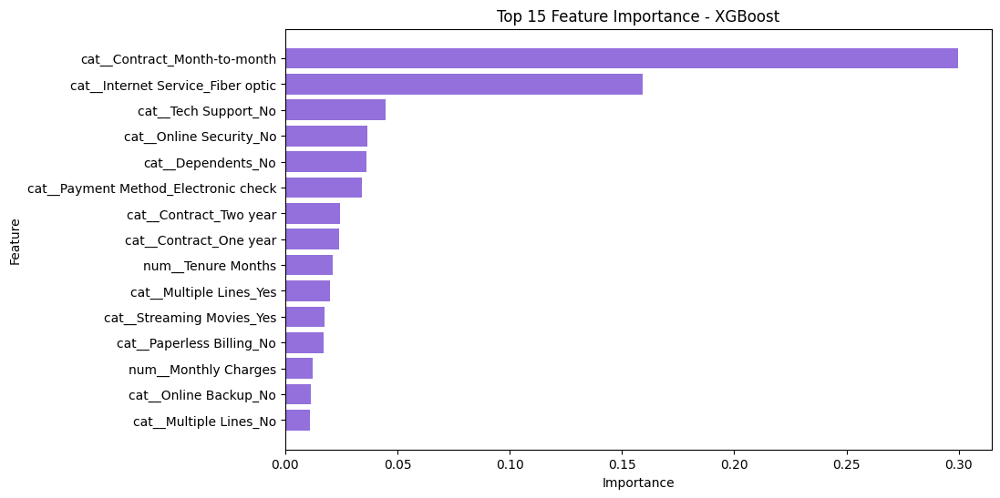

In [54]:
plt.figure(figsize=(10, 6))

plt.barh(
    feature_importance.head(15)['Feature'],
    feature_importance.head(15)['Importance'],
    color='mediumpurple'
)

plt.xlabel('Importance')
plt.ylabel('Feature')
plt.title('Top 15 Feature Importance - XGBoost')

plt.gca().invert_yaxis()

plt.show()

### Feature Importance Observation

The feature importance results show which customer characteristics have the greatest influence on the XGBoost model.

The most important features can be examined from a business perspective to understand factors associated with customer churn.

## 6.5 Model Complexity Experiment

The effect of model complexity is examined by changing the XGBoost tree depth while keeping the other parameters fixed.

A smaller tree depth produces a simpler model, while a larger depth allows the model to learn more complex patterns.

Training and validation performance are compared to observe whether increasing complexity improves generalization or increases the risk of overfitting.

In [55]:
xgb_complex = Pipeline(
    steps=[
        ('preprocessor', preprocessor_fe),
        ('classifier', XGBClassifier(
            n_estimators=200,
            learning_rate=0.05,
            max_depth=6,
            random_state=42,
            eval_metric='logloss'
        ))
    ]
)

xgb_complex.fit(
    X_train_fe,
    y_train
)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](34,)","['CustomerID','Count','Country',...,'Tenure_Category','Contract_Risk', 'Log_Total_Charges']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,34
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remain

In [56]:
y_train_pred_complex = xgb_complex.predict(X_train_fe)

y_val_pred_complex = xgb_complex.predict(X_val_fe)

y_val_prob_complex = xgb_complex.predict_proba(
    X_val_fe
)[:, 1]

complexity_results = {
    "Train Accuracy": accuracy_score(
        y_train,
        y_train_pred_complex
    ),
    "Validation Accuracy": accuracy_score(
        y_val,
        y_val_pred_complex
    ),
    "Validation F1": f1_score(
        y_val,
        y_val_pred_complex
    ),
    "Validation ROC-AUC": roc_auc_score(
        y_val,
        y_val_prob_complex
    )
}

complexity_results

{'Train Accuracy': 0.8981744421906693,
 'Validation Accuracy': 0.8039772727272727,
 'Validation F1': 0.6130841121495327,
 'Validation ROC-AUC': 0.8479519513991164}

### Complexity Experiment Observation

The training and validation performance are compared to understand the effect of increasing tree depth.

A large difference between training and validation performance may indicate overfitting, while similar performance suggests better generalization.

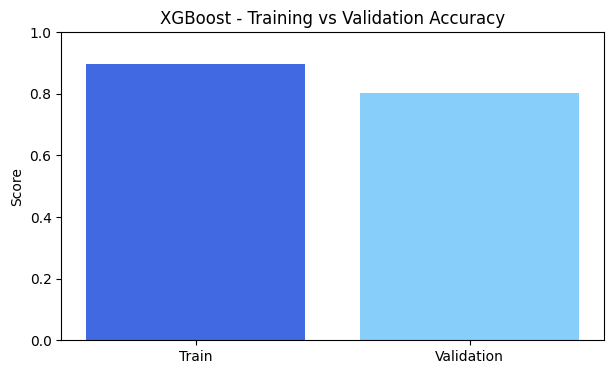

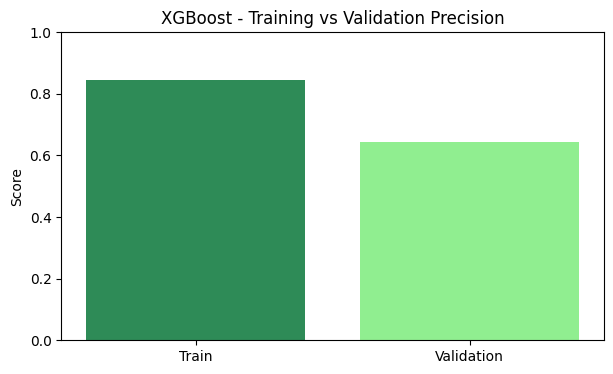

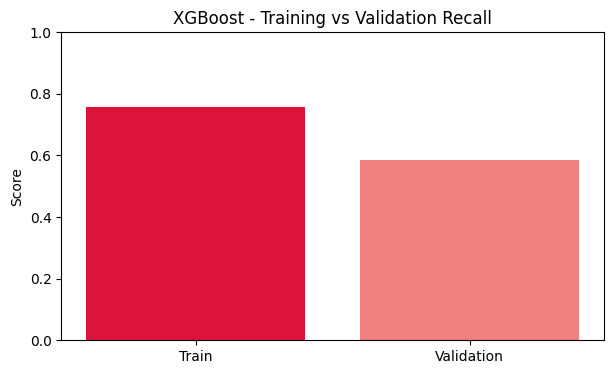

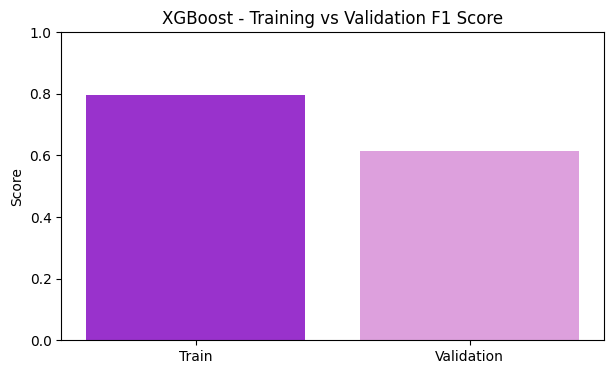

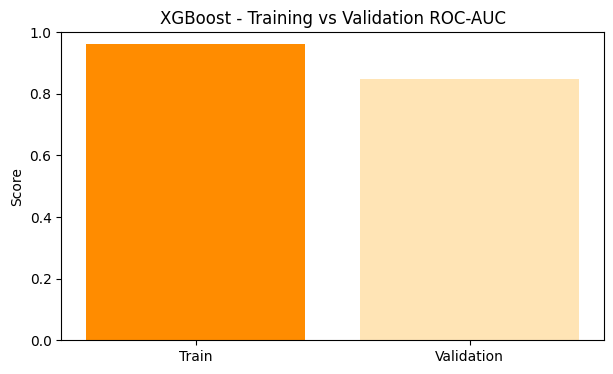

In [57]:
import matplotlib.pyplot as plt

# Predictions
y_train_pred_complex = xgb_complex.predict(X_train_fe)
y_train_prob_complex = xgb_complex.predict_proba(X_train_fe)[:, 1]

y_val_pred_complex = xgb_complex.predict(X_val_fe)
y_val_prob_complex = xgb_complex.predict_proba(X_val_fe)[:, 1]


# Metrics
metrics = {
    "Accuracy": [
        accuracy_score(y_train, y_train_pred_complex),
        accuracy_score(y_val, y_val_pred_complex)
    ],
    "Precision": [
        precision_score(y_train, y_train_pred_complex),
        precision_score(y_val, y_val_pred_complex)
    ],
    "Recall": [
        recall_score(y_train, y_train_pred_complex),
        recall_score(y_val, y_val_pred_complex)
    ],
    "F1 Score": [
        f1_score(y_train, y_train_pred_complex),
        f1_score(y_val, y_val_pred_complex)
    ],
    "ROC-AUC": [
        roc_auc_score(y_train, y_train_prob_complex),
        roc_auc_score(y_val, y_val_prob_complex)
    ]
}


# Separate Accuracy graph
plt.figure(figsize=(7, 4))
plt.bar(["Train", "Validation"], metrics["Accuracy"],
        color=["royalblue", "lightskyblue"])
plt.ylim(0, 1)
plt.ylabel("Score")
plt.title("XGBoost - Training vs Validation Accuracy")
plt.show()


# Separate Precision graph
plt.figure(figsize=(7, 4))
plt.bar(["Train", "Validation"], metrics["Precision"],
        color=["seagreen", "lightgreen"])
plt.ylim(0, 1)
plt.ylabel("Score")
plt.title("XGBoost - Training vs Validation Precision")
plt.show()


# Separate Recall graph
plt.figure(figsize=(7, 4))
plt.bar(["Train", "Validation"], metrics["Recall"],
        color=["crimson", "lightcoral"])
plt.ylim(0, 1)
plt.ylabel("Score")
plt.title("XGBoost - Training vs Validation Recall")
plt.show()


# Separate F1 graph
plt.figure(figsize=(7, 4))
plt.bar(["Train", "Validation"], metrics["F1 Score"],
        color=["darkorchid", "plum"])
plt.ylim(0, 1)
plt.ylabel("Score")
plt.title("XGBoost - Training vs Validation F1 Score")
plt.show()


# Separate ROC-AUC graph
plt.figure(figsize=(7, 4))
plt.bar(["Train", "Validation"], metrics["ROC-AUC"],
        color=["darkorange", "moccasin"])
plt.ylim(0, 1)
plt.ylabel("Score")
plt.title("XGBoost - Training vs Validation ROC-AUC")
plt.show()

## 6.6 Bagging vs Boosting

### Bagging

Bagging (Bootstrap Aggregating) trains multiple models independently on different bootstrap samples of the training data and combines their predictions.

**Example:** Random Forest

The main objective of bagging is to reduce variance and improve model stability.

### Boosting

Boosting trains models sequentially, where each new model focuses on correcting errors made by the previous models.

**Example:** XGBoost

The main objective of boosting is to build a strong predictive model by gradually improving the errors made by earlier models.

### Key Difference

| Aspect | Bagging | Boosting |
|---|---|---|
| Training | Parallel | Sequential |
| Main purpose | Reduce variance | Improve predictive performance |
| Example | Random Forest | XGBoost |
| Error handling | Models learn independently | Each model learns from previous errors |
| Overfitting risk | Generally lower | Can be higher if model complexity is not controlled |

In this project, Random Forest represents the bagging approach, while XGBoost represents the boosting approach.

# Task 7: Hyperparameter Tuning with Cross-Validation

Hyperparameter tuning is performed to identify model configurations that improve generalization performance.

GridSearchCV is used to evaluate a reasonable set of hyperparameter combinations using cross-validation on the training data.

The held-out test set is not used during hyperparameter tuning or model selection to avoid data leakage and preserve an unbiased final evaluation.

## 7.1 Random Forest Hyperparameter Tuning

The Random Forest model is tuned using GridSearchCV.

The search focuses on a small set of hyperparameters that control the size and complexity of the forest.

In [58]:
from sklearn.model_selection import GridSearchCV

rf_param_grid = {
    'classifier__n_estimators': [100, 200],
    'classifier__max_depth': [5, 10],
    'classifier__min_samples_split': [2, 5]
}

In [59]:
rf_grid = GridSearchCV(
    estimator=rf_model,
    param_grid=rf_param_grid,
    cv=3,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=1
)

In [60]:
rf_grid.fit(
    X_train_fe,
    y_train
)

Fitting 3 folds for each of 8 candidates, totalling 24 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'classifier__max_depth': [5, 10], 'classifier__min_samples_split': [2, 5], 'classifier__n_estimators': [100, 200]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'roc_auc'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",3
,"verbose verbose: int, default=0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_

### Best Random Forest Configuration

The best hyperparameter combination is selected based on the highest mean cross-validation ROC-AUC score.

In [61]:
print("Best Parameters:")
print(rf_grid.best_params_)

print("\nBest Cross-Validated ROC-AUC:")
print(rf_grid.best_score_)

Best Parameters:
{'classifier__max_depth': 10, 'classifier__min_samples_split': 5, 'classifier__n_estimators': 200}

Best Cross-Validated ROC-AUC:
0.8499823684425255


## 7.2 XGBoost Hyperparameter Tuning

The XGBoost model is tuned using GridSearchCV to identify a configuration that provides strong cross-validation performance.

A small search space is used for parameters controlling tree complexity and boosting behaviour.

In [62]:
xgb_param_grid = {
    'classifier__n_estimators': [100, 200],
    'classifier__max_depth': [3, 5],
    'classifier__learning_rate': [0.05, 0.1]
}

In [63]:
xgb_grid = GridSearchCV(
    estimator=xgb_model,
    param_grid=xgb_param_grid,
    cv=3,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=1
)

In [64]:
xgb_grid.fit(
    X_train_fe,
    y_train
)

Fitting 3 folds for each of 8 candidates, totalling 24 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","Pipeline(step...=None, ...))])"
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'classifier__learning_rate': [0.05, 0.1], 'classifier__max_depth': [3, 5], 'classifier__n_estimators': [100, 200]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'roc_auc'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",3
,"verbose verbose: int, default=0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_example

In [65]:
print("Best Parameters:")
print(xgb_grid.best_params_)

print("\nBest Cross-Validated ROC-AUC:")
print(xgb_grid.best_score_)

Best Parameters:
{'classifier__learning_rate': 0.05, 'classifier__max_depth': 3, 'classifier__n_estimators': 100}

Best Cross-Validated ROC-AUC:
0.8627353242276982


## Cross-Validation Tuning Summary

Both tree-based models were tuned using 3-fold cross-validation on the training dataset.

Random Forest achieved a best cross-validated ROC-AUC of approximately 0.850, while XGBoost achieved approximately 0.863.

Based on cross-validated ROC-AUC, XGBoost showed stronger performance among the two tuned tree-based models. The held-out test set was not used during hyperparameter tuning or model selection.

# Task 8: Fair Model Comparison

The baseline Logistic Regression, tuned Random Forest, and tuned XGBoost models are compared using the same validation dataset and the same evaluation methodology.

ROC-AUC is used as the primary evaluation metric, while F1-score is included as a supporting metric because the churn dataset contains class imbalance.

The final model is selected based on validation performance, while also considering model complexity and interpretability.

## 8.1 Validation Performance of Tuned Models

The best estimators identified through cross-validation are evaluated on the same validation dataset used for the earlier model comparison.

The held-out test set remains untouched.

In [66]:
# Best models selected during cross-validation

best_rf_model = rf_grid.best_estimator_
best_xgb_model = xgb_grid.best_estimator_


# Validation predictions

y_val_pred_rf_tuned = best_rf_model.predict(X_val_fe)
y_val_prob_rf_tuned = best_rf_model.predict_proba(X_val_fe)[:, 1]

y_val_pred_xgb_tuned = best_xgb_model.predict(X_val_fe)
y_val_prob_xgb_tuned = best_xgb_model.predict_proba(X_val_fe)[:, 1]

## 8.2 Validation Metrics for Tuned Models

The tuned Random Forest and XGBoost models are evaluated on the same validation dataset using the same evaluation metrics.

ROC-AUC is used as the primary metric, while F1-score is included as a supporting metric.

In [67]:
rf_tuned_results = {
    "Accuracy": accuracy_score(y_val, y_val_pred_rf_tuned),
    "Precision": precision_score(y_val, y_val_pred_rf_tuned),
    "Recall": recall_score(y_val, y_val_pred_rf_tuned),
    "F1 Score": f1_score(y_val, y_val_pred_rf_tuned),
    "ROC-AUC": roc_auc_score(y_val, y_val_prob_rf_tuned)
}

xgb_tuned_results = {
    "Accuracy": accuracy_score(y_val, y_val_pred_xgb_tuned),
    "Precision": precision_score(y_val, y_val_pred_xgb_tuned),
    "Recall": recall_score(y_val, y_val_pred_xgb_tuned),
    "F1 Score": f1_score(y_val, y_val_pred_xgb_tuned),
    "ROC-AUC": roc_auc_score(y_val, y_val_prob_xgb_tuned)
}

In [68]:
comparison_table = pd.DataFrame([
    {
        "Model": "Logistic Regression",
        "ROC-AUC": baseline_results["ROC-AUC"],
        "F1 Score": baseline_results["F1 Score"]
    },
    {
        "Model": "Tuned Random Forest",
        "ROC-AUC": rf_tuned_results["ROC-AUC"],
        "F1 Score": rf_tuned_results["F1 Score"]
    },
    {
        "Model": "Tuned XGBoost",
        "ROC-AUC": xgb_tuned_results["ROC-AUC"],
        "F1 Score": xgb_tuned_results["F1 Score"]
    }
])

comparison_table

,Model,ROC-AUC,F1 Score
0,Logistic Regression,0.834854,0.583630
1,Tuned Random Forest,0.841711,0.316384
2,Tuned XGBoost,0.853452,0.584139


## 8.3 Final Model Selection

Tuned XGBoost achieved the highest validation ROC-AUC score of 0.8535 among the three models, outperforming Logistic Regression (0.8349) and Tuned Random Forest (0.8415).

The F1-score of XGBoost (0.5792) is slightly lower than the Logistic Regression baseline (0.5836), indicating that the improvement is mainly in the model's ability to distinguish between churn and non-churn customers.

Despite the additional complexity of XGBoost compared with Logistic Regression, the improvement in the primary ROC-AUC metric makes XGBoost the preferred final model for this project.

In [69]:
final_model_name = "Tuned XGBoost"

print("Selected Final Model:", final_model_name)
print("Validation ROC-AUC:", xgb_tuned_results["ROC-AUC"])
print("Validation F1 Score:", xgb_tuned_results["F1 Score"])

Selected Final Model: Tuned XGBoost
Validation ROC-AUC: 0.8534517673048602
Validation F1 Score: 0.5841392649903289


# Task 9: Final Test Evaluation

The tuned XGBoost model was selected as the final model based on the validation performance in Task 8.

The held-out test dataset is now used for the final evaluation. This dataset was not used during model training, hyperparameter tuning, or model selection.

## 9.1 Final Test Predictions

The selected tuned XGBoost model is evaluated once on the untouched test dataset.

Prediction classes and probabilities are generated for calculating the final evaluation metrics.

In [70]:
# Final test predictions using the selected model

y_test_pred = best_xgb_model.predict(X_test_fe)
y_test_prob = best_xgb_model.predict_proba(X_test_fe)[:, 1]

## 9.2 Final Test Performance

The selected tuned XGBoost model is evaluated on the held-out test dataset using the same metrics used during validation.

These results represent the final performance of the selected model on unseen customer data.

In [71]:
final_test_results = {
    "Accuracy": accuracy_score(y_test, y_test_pred),
    "Precision": precision_score(y_test, y_test_pred),
    "Recall": recall_score(y_test, y_test_pred),
    "F1 Score": f1_score(y_test, y_test_pred),
    "ROC-AUC": roc_auc_score(y_test, y_test_prob)
}

final_test_results

{'Accuracy': 0.8013245033112583,
 'Precision': 0.6714975845410628,
 'Recall': 0.49466192170818507,
 'F1 Score': 0.569672131147541,
 'ROC-AUC': 0.858543218255861}

## 9.3 Validation vs Test Performance

The final tuned XGBoost model is compared across the validation and held-out test datasets using the same evaluation metrics.

This comparison helps determine whether the model generalizes consistently to unseen data.

In [72]:
validation_vs_test = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "ROC-AUC"
    ],
    "Validation": [
        xgb_tuned_results["Accuracy"],
        xgb_tuned_results["Precision"],
        xgb_tuned_results["Recall"],
        xgb_tuned_results["F1 Score"],
        xgb_tuned_results["ROC-AUC"]
    ],
    "Test": [
        final_test_results["Accuracy"],
        final_test_results["Precision"],
        final_test_results["Recall"],
        final_test_results["F1 Score"],
        final_test_results["ROC-AUC"]
    ]
})

validation_vs_test

,Metric,Validation,Test
0,Accuracy,0.796402,0.801325
1,Precision,0.637131,0.671498
2,Recall,0.539286,0.494662
3,F1 Score,0.584139,0.569672
4,ROC-AUC,0.853452,0.858543


## 9.4 Validation vs Test Gap Analysis

The differences between validation and test performance are examined to assess how consistently the final model generalizes to unseen data.

A small performance gap generally indicates consistent generalization, while a larger gap may indicate differences in the validation and test samples or possible overfitting.

In [73]:
gap_analysis = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "ROC-AUC"
    ],
    "Validation": [
        xgb_tuned_results["Accuracy"],
        xgb_tuned_results["Precision"],
        xgb_tuned_results["Recall"],
        xgb_tuned_results["F1 Score"],
        xgb_tuned_results["ROC-AUC"]
    ],
    "Test": [
        final_test_results["Accuracy"],
        final_test_results["Precision"],
        final_test_results["Recall"],
        final_test_results["F1 Score"],
        final_test_results["ROC-AUC"]
    ]
})

gap_analysis["Absolute Gap"] = (
    gap_analysis["Test"] - gap_analysis["Validation"]
).abs()

gap_analysis

,Metric,Validation,Test,Absolute Gap
0,Accuracy,0.796402,0.801325,0.004923
1,Precision,0.637131,0.671498,0.034367
2,Recall,0.539286,0.494662,0.044624
3,F1 Score,0.584139,0.569672,0.014467
4,ROC-AUC,0.853452,0.858543,0.005091


### Gap Interpretation

The validation and test results show how the selected XGBoost model performs on unseen data.

The final test ROC-AUC should be compared with the validation ROC-AUC to determine whether the model maintains similar discriminatory performance on unseen customers.

Any observed differences are considered in the context of normal variation between the validation and test datasets.

## Task 10: Error Analysis

Error analysis is performed on the predictions made by the selected final model on the held-out test dataset.

The purpose is to inspect incorrect predictions and identify patterns that may explain where the model performs poorly.

In [74]:
# Create an error-analysis dataframe

error_analysis = X_test_fe.copy()

error_analysis["Actual"] = y_test.values
error_analysis["Predicted"] = y_test_pred
error_analysis["Prediction_Probability"] = y_test_prob

# Keep only incorrect predictions

incorrect_predictions = error_analysis[
    error_analysis["Actual"] != error_analysis["Predicted"]
].copy()

incorrect_predictions.head()

,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,Senior Citizen,Partner,Dependents,Tenure Months,Phone Service,Multiple Lines,Internet Service,Online Security,Online Backup,Device Protection,Tech Support,Streaming TV,Streaming Movies,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,CLTV,Avg_Monthly_Spend,Total_Services,Tenure_Category,Contract_Risk,Log_Total_Charges,Actual,Predicted,Prediction_Probability
430,4690-LLKUA,1,United States,California,Topaz,96133,"38.636052, -119.489162",38.636052,-119.489162,Male,Yes,No,No,17,Yes,No,DSL,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,45.05,770.60,3797,45.329412,2,Medium,High,6.648466,1,0,0.385157
2253,6705-LXORM,1,United States,California,Perris,92570,"33.787298, -117.320676",33.787298,-117.320676,Female,Yes,Yes,No,5,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,No,Electronic check,70.05,302.60,2064,60.520000,2,New,High,5.715711,0,1,0.582676
1618,0870-VEMYL,1,United States,California,Columbia,95310,"38.085839, -120.37855",38.085839,-120.378550,Female,No,No,No,5,Yes,No,DSL,Yes,No,No,Yes,No,No,Month-to-month,No,Credit card (automatic),53.85,259.80,5435,51.960000,4,New,High,5.563754,1,0,0.176955
848,9710-ZUSHQ,1,United States,California,Red Bluff,96080,"40.186772, -122.388361",40.186772,-122.388361,Female,Yes,No,No,37,Yes,Yes,Fiber optic,Yes,Yes,No,No,Yes,Yes,Month-to-month,Yes,Bank transfer (automatic),106.75,4056.75,5849,109.641892,3,Long,High,8.308384,1,0,0.413439
881,3658-KIBGF,1,United States,California,Los Angeles,90068,"34.137411, -118.328915",34.137411,-118.328915,Female,No,No,No,1,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,54.90,54.90,2833,54.900000,3,New,High,4.023564,1,0,0.482087


## 10.1 Incorrect Predictions

The incorrect predictions are separated from the complete test-set predictions to examine cases where the final model predicted the wrong churn outcome.

In [75]:
print("Total test observations:", len(error_analysis))
print("Incorrect predictions:", len(incorrect_predictions))
print(
    "Error rate:",
    len(incorrect_predictions) / len(error_analysis)
)

Total test observations: 1057
Incorrect predictions: 210
Error rate: 0.1986754966887417


## 10.2 Error Pattern by Contract Type

The distribution of incorrect predictions is examined across contract types to identify whether the final model makes more errors for particular customer segments.

In [76]:
contract_error_analysis = (
    incorrect_predictions["Contract"]
    .value_counts()
    .reset_index()
)

contract_error_analysis.columns = [
    "Contract",
    "Incorrect_Predictions"
]

contract_error_analysis

,Contract,Incorrect_Predictions
0,Month-to-month,172
1,One year,33
2,Two year,5


In [77]:
contract_performance = (
    error_analysis
    .groupby("Contract")
    .agg(
        Total_Customers=("Actual", "size"),
        Incorrect_Predictions=(
            "Predicted",
            lambda x: (x != error_analysis.loc[x.index, "Actual"]).sum()
        )
    )
)

contract_performance["Error_Rate"] = (
    contract_performance["Incorrect_Predictions"]
    / contract_performance["Total_Customers"]
)

contract_performance

,Total_Customers,Incorrect_Predictions,Error_Rate
Contract,,,
Month-to-month,572,172,0.300699
One year,229,33,0.144105
Two year,256,5,0.019531


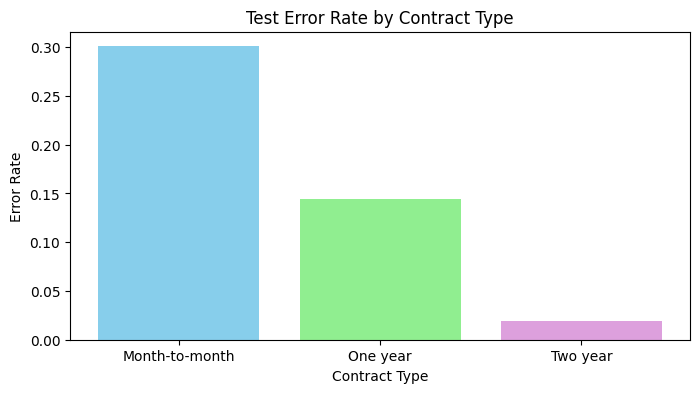

In [78]:
plt.figure(figsize=(8, 4))

plt.bar(
    contract_performance.index,
    contract_performance["Error_Rate"],
    color=["skyblue", "lightgreen", "plum"]
)

plt.ylabel("Error Rate")
plt.xlabel("Contract Type")
plt.title("Test Error Rate by Contract Type")

plt.show()

### Error Pattern Observation

The highest error rate is observed for month-to-month contract customers.

This suggests that the final model has greater difficulty distinguishing churn behaviour within this customer segment.

## 10.3 Potential Improvement

One improvement that could be investigated next is probability-threshold tuning using the validation dataset.

A threshold different from the default 0.5 could be explored to improve the balance between recall and precision and potentially identify more churn-prone customers.

# Task 11: Post-Training Visual Analysis

After training and selecting the final model, visual analysis is performed using the actual experiment results.

The visualizations compare model performance, evaluate the final model on the held-out test set, examine the ROC and Precision–Recall behaviour, identify important features, and analyze patterns in prediction errors.

All visualizations are based on the actual validation and test results obtained during the modelling workflow.

## 11.1 Model Performance Comparison

The primary validation metric, ROC-AUC, is compared across the baseline Logistic Regression, tuned Random Forest, and tuned XGBoost models.

The comparison uses the same validation dataset and evaluation methodology used during model selection.

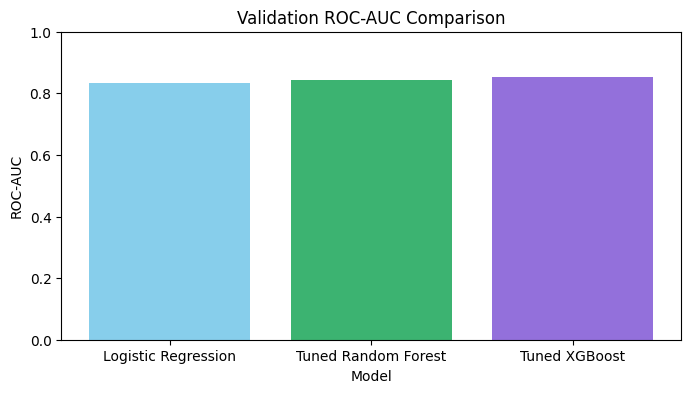

In [79]:
plt.figure(figsize=(8, 4))

plt.bar(
    comparison_table["Model"],
    comparison_table["ROC-AUC"],
    color=["skyblue", "mediumseagreen", "mediumpurple"]
)

plt.xlabel("Model")
plt.ylabel("ROC-AUC")
plt.ylim(0, 1)
plt.title("Validation ROC-AUC Comparison")

plt.show()

### Key Insight

Tuned XGBoost achieved the highest validation ROC-AUC among the three evaluated models.

This supports its selection as the final model for the final test evaluation.

## 11.2 Confusion Matrix

The confusion matrix shows the classification performance of the final tuned XGBoost model on the held-out test dataset.

It displays true positives, true negatives, false positives, and false negatives to show the types of predictions made by the model.

<Figure size 600x500 with 0 Axes>

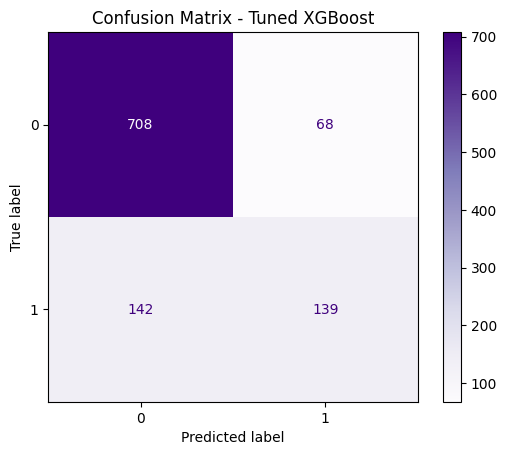

In [80]:
from sklearn.metrics import ConfusionMatrixDisplay

plt.figure(figsize=(6, 5))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_test_pred,
    cmap="Purples",
    values_format="d"
)

plt.title("Confusion Matrix - Tuned XGBoost")

plt.show()

### Key Insight

The confusion matrix shows how the final XGBoost model classifies churn and non-churn customers on unseen test data.

The distribution of false positives and false negatives helps identify the types of classification errors made by the model.

## 11.3 ROC Curve

The ROC curve illustrates the trade-off between the true positive rate and false positive rate of the final tuned XGBoost model across different classification thresholds.

The area under the ROC curve (ROC-AUC) summarizes the model's ability to distinguish between churn and non-churn customers.

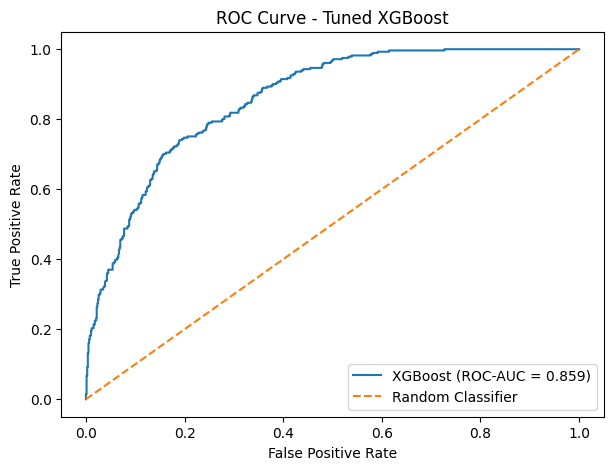

In [81]:
from sklearn.metrics import roc_curve, roc_auc_score

fpr, tpr, _ = roc_curve(
    y_test,
    y_test_prob
)

roc_auc = roc_auc_score(
    y_test,
    y_test_prob
)

plt.figure(figsize=(7, 5))

plt.plot(
    fpr,
    tpr,
    label=f"XGBoost (ROC-AUC = {roc_auc:.3f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Tuned XGBoost")
plt.legend()

plt.show()

### Key Insight

The ROC curve shows the ability of the final XGBoost model to distinguish between churn and non-churn customers across different classification thresholds.

The ROC-AUC value summarizes this overall discriminatory performance on the held-out test dataset.

## 11.4 Precision–Recall Curve

The Precision–Recall curve illustrates the trade-off between precision and recall for the final tuned XGBoost model across different classification thresholds.

PR-AUC provides a summary of this trade-off and is particularly useful for evaluating classification performance when the target classes are imbalanced.

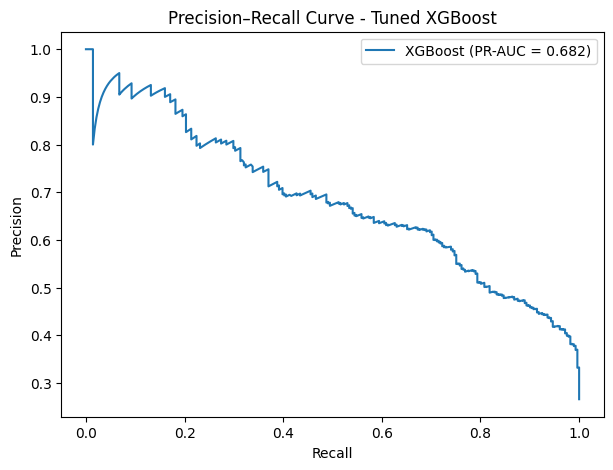

In [82]:
from sklearn.metrics import precision_recall_curve, auc

precision, recall, _ = precision_recall_curve(
    y_test,
    y_test_prob
)

pr_auc = auc(
    recall,
    precision
)

plt.figure(figsize=(7, 5))

plt.plot(
    recall,
    precision,
    label=f"XGBoost (PR-AUC = {pr_auc:.3f})"
)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision–Recall Curve - Tuned XGBoost")
plt.legend()

plt.show()

### Key Insight

The Precision–Recall curve shows the trade-off between identifying more churn customers and maintaining prediction precision.

The PR-AUC value summarizes the model's performance across different classification thresholds and is useful for assessing the final model on the imbalanced churn dataset.

## 11.5 Feature Importance

The top 10 feature importance scores of the final tuned XGBoost model are visualized to identify the customer attributes that contribute most to the model's predictions.

The feature importance values are obtained from the trained XGBoost estimator after preprocessing.

In [83]:
# Extract feature names and importance from the final XGBoost model

final_feature_names = best_xgb_model.named_steps[
    'preprocessor'
].get_feature_names_out()

final_importance_values = best_xgb_model.named_steps[
    'classifier'
].feature_importances_

final_feature_importance = pd.DataFrame({
    'Feature': final_feature_names,
    'Importance': final_importance_values
}).sort_values(
    by='Importance',
    ascending=False
)

top_10_features = final_feature_importance.head(10)

top_10_features

,Feature,Importance
7745,cat__Contract_Month-to-month,0.308661
7736,cat__Tech Support_No,0.093703
7725,cat__Internet Service_Fiber optic,0.092117
7727,cat__Online Security_No,0.080254
7752,cat__Payment Method_Electronic check,0.048163
7717,cat__Dependents_No,0.040102
7747,cat__Contract_Two year,0.030987
4,num__Tenure Months,0.028740
7746,cat__Contract_One year,0.026576
7726,cat__Internet Service_No,0.024686


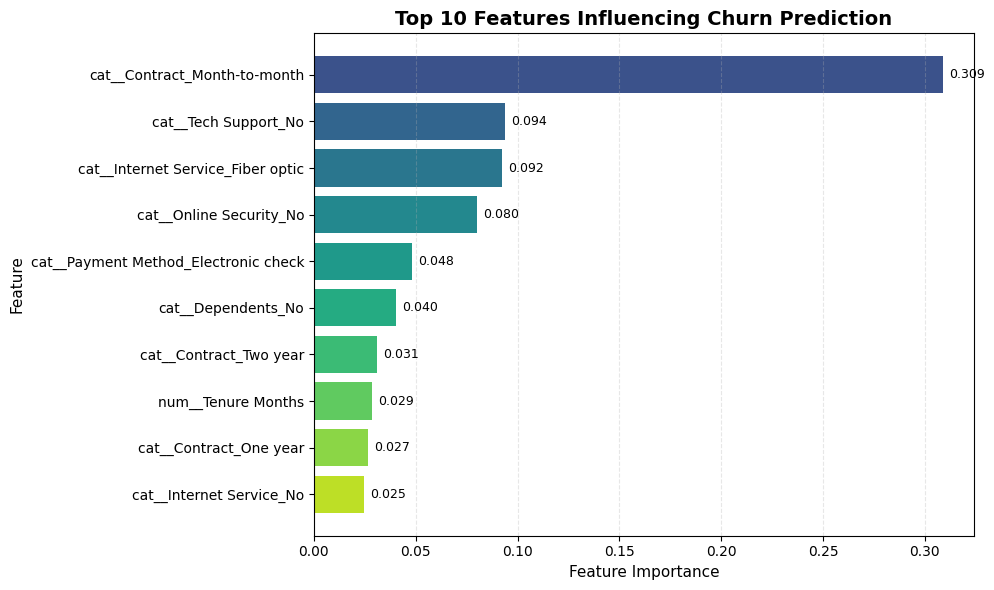

In [84]:
plt.figure(figsize=(10, 6))

colors = plt.cm.viridis(
    np.linspace(0.25, 0.9, len(top_10_features))
)

bars = plt.barh(
    top_10_features['Feature'],
    top_10_features['Importance'],
    color=colors
)

plt.xlabel("Feature Importance", fontsize=11)
plt.ylabel("Feature", fontsize=11)
plt.title(
    "Top 10 Features Influencing Churn Prediction",
    fontsize=14,
    fontweight="bold"
)

plt.gca().invert_yaxis()

# Add values at the end of each bar
for bar in bars:
    width = bar.get_width()
    plt.text(
        width + 0.003,
        bar.get_y() + bar.get_height() / 2,
        f"{width:.3f}",
        va="center",
        fontsize=9
    )

plt.grid(
    axis="x",
    linestyle="--",
    alpha=0.3
)

plt.tight_layout()
plt.show()

## 11.6 Error Analysis by Contract Type

The error rate of the final tuned XGBoost model is examined across different contract types.

This helps identify whether the model has greater difficulty predicting churn for specific customer segments.

In [85]:
# Calculate error rate by contract type

error_by_contract = (
    error_analysis
    .groupby("Contract")
    .apply(
        lambda group: pd.Series({
            "Total_Customers": len(group),
            "Incorrect_Predictions": (
                group["Actual"] != group["Predicted"]
            ).sum(),
            "Error_Rate": (
                group["Actual"] != group["Predicted"]
            ).mean()
        }),
        include_groups=False
    )
)

error_by_contract

,Total_Customers,Incorrect_Predictions,Error_Rate
Contract,,,
Month-to-month,572.0,172.0,0.300699
One year,229.0,33.0,0.144105
Two year,256.0,5.0,0.019531


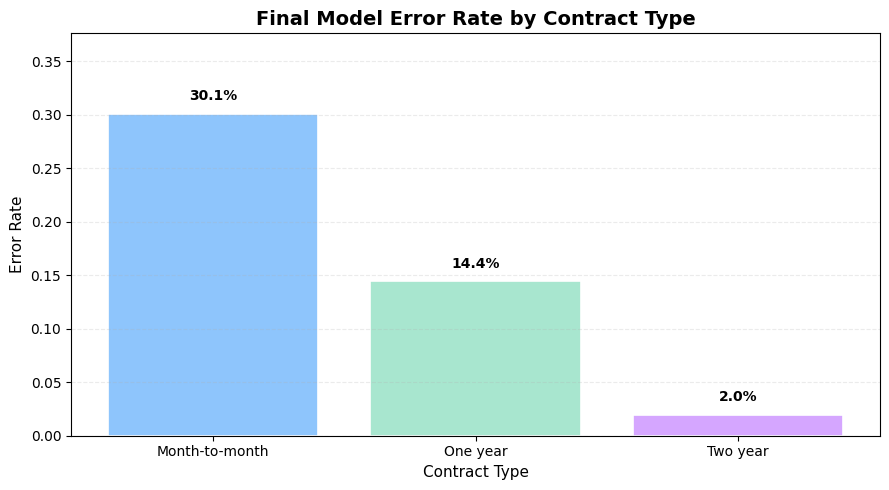

In [86]:
plt.figure(figsize=(9, 5))

bars = plt.bar(
    error_by_contract.index,
    error_by_contract["Error_Rate"],
    color=["#8EC5FC", "#A8E6CF", "#D5A6FF"],
    edgecolor="white",
    linewidth=1.2
)

plt.xlabel("Contract Type", fontsize=11)
plt.ylabel("Error Rate", fontsize=11)
plt.title(
    "Final Model Error Rate by Contract Type",
    fontsize=14,
    fontweight="bold"
)

plt.ylim(0, max(error_by_contract["Error_Rate"]) * 1.25)

# Add percentage labels
for bar, value in zip(
    bars,
    error_by_contract["Error_Rate"]
):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.01,
        f"{value:.1%}",
        ha="center",
        va="bottom",
        fontsize=10,
        fontweight="bold"
    )

plt.grid(
    axis="y",
    linestyle="--",
    alpha=0.25
)

plt.tight_layout()
plt.show()

### Key Insight

The error rates vary across contract types, indicating that the final model does not perform equally well for all customer segments.

The contract type with the highest observed error rate represents a segment where the model has greater difficulty distinguishing churn behaviour.

# Task 12: Create and Save the Final Pipeline

The final tuned XGBoost model and all required preprocessing steps are combined into a single scikit-learn Pipeline.

The Pipeline is designed to accept raw customer input data and apply the required transformations consistently before generating predictions.

The fitted Pipeline is evaluated and saved as a single serialized artifact so that it can be loaded later for prediction without retraining or manually recreating the preprocessing steps.

## 12.1 Feature Engineering Transformer

The feature-engineering operations developed in Task 4 are incorporated into a reusable transformer.

This allows the final Pipeline to accept raw customer data and automatically create the engineered features required by the model.

In [87]:
from src.feature_engineering import FeatureEngineer

In [88]:
# Test it before building the final Pipeline
feature_engineer = FeatureEngineer()

X_test_transform = feature_engineer.transform(
    X_train.head()
)

X_test_transform[
    [
        'Avg_Monthly_Spend',
        'Total_Services',
        'Tenure_Category',
        'Contract_Risk',
        'Log_Total_Charges'
    ]
]

,Avg_Monthly_Spend,Total_Services,Tenure_Category,Contract_Risk,Log_Total_Charges
5963,76.850000,2,New,High,5.953892
596,73.650000,2,New,High,5.402452
1836,72.250000,2,New,High,5.383348
3535,80.784167,3,Long,Low,8.486332
228,93.412500,4,New,High,7.022824


## 12.2 Complete Final Pipeline

The feature-engineering transformer, preprocessing pipeline, and selected XGBoost estimator are combined into one end-to-end Pipeline.

This ensures that raw customer records can be passed directly to the model while all required transformations are applied consistently.

In [89]:
final_pipeline = Pipeline(
    steps=[
        ('feature_engineering', FeatureEngineer()),
        ('preprocessor', preprocessor_fe),
        ('classifier', XGBClassifier(
            n_estimators=100,
            learning_rate=0.05,
            max_depth=3,
            random_state=42,
            eval_metric='logloss'
        ))
    ]
)

## 12.3 Fitting the Final Pipeline

The complete Pipeline is fitted using the original training data.

Feature engineering and preprocessing are performed internally by the Pipeline before the final XGBoost estimator is trained.

In [90]:
final_pipeline.fit(
    X_train,
    y_train
)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('feature_engineering', ...), ('preprocessor', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note

## Step 12.4 — Validate the complete pipeline

In [91]:
final_pipeline_val_prob = final_pipeline.predict_proba(
    X_val
)[:, 1]

final_pipeline_val_pred = final_pipeline.predict(
    X_val
)

print(
    "Validation ROC-AUC:",
    roc_auc_score(y_val, final_pipeline_val_prob)
)

print(
    "Validation F1 Score:",
    f1_score(y_val, final_pipeline_val_pred)
)

Validation ROC-AUC: 0.8535115979381444
Validation F1 Score: 0.5791505791505791


## 12.5 Save the Final Pipeline

The complete fitted Pipeline is serialized using joblib and saved as a single model artifact.

The saved artifact contains the feature-engineering transformer, preprocessing steps, and final XGBoost estimator, allowing predictions to be made later without retraining or manually recreating the transformations.

In [92]:
import joblib
import os

os.makedirs("model", exist_ok=True)

pipeline_path = "model/final_pipeline.joblib"

joblib.dump(
    final_pipeline,
    pipeline_path
)

print("Final Pipeline saved to:", pipeline_path)

Final Pipeline saved to: model/final_pipeline.joblib


In [93]:
os.path.exists(pipeline_path)

True

## 12.6 Verify the Saved Pipeline

The saved Pipeline is loaded from disk and used to generate predictions on raw validation data.

This confirms that the complete feature engineering, preprocessing, and model steps are stored together and that the model can make predictions without retraining.

In [94]:
# Load the saved Pipeline

loaded_pipeline = joblib.load(
    pipeline_path
)

# Generate predictions from raw validation data

loaded_val_pred = loaded_pipeline.predict(X_val)
loaded_val_prob = loaded_pipeline.predict_proba(X_val)[:, 1]

print("Loaded Pipeline Validation ROC-AUC:",
      roc_auc_score(y_val, loaded_val_prob))

print("Loaded Pipeline Validation F1 Score:",
      f1_score(y_val, loaded_val_pred))

Loaded Pipeline Validation ROC-AUC: 0.8535115979381444
Loaded Pipeline Validation F1 Score: 0.5791505791505791


### Pipeline Verification Result

The saved Pipeline was successfully loaded and generated predictions from raw customer data without retraining.

The validation performance remains consistent with the fitted final Pipeline, confirming that the saved artifact contains the required feature engineering, preprocessing, and final model components.